# Bangladesh Road Accident Analysis 

In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [133]:
df = pd.read_csv("data/road_accidents_bangladesh_cleaned.csv")
df.head()

,id,title,date,article_url,place_of_accident,district,number_of_deaths,number_of_injured,vehicle_type,cause_of_accident,country,report_type,type_of_accident
0,6,"Road accident in Cox’s Bazar leaves 3 dead, 7 ...",2025-06-16 11:43:58,https://en.prothomalo.com/bangladesh/accident/...,chattogram-cox’s bazar highway in ramu upazila,cox’s bazar,3,7,passenger bus and a covered van,head-on collision,Bangladesh,event,road accident
1,8,"Two killed, four injured in Khulna road accident",2025-06-09 12:29:25,https://en.prothomalo.com/bangladesh/accident/...,darogar bhita area near rupsha bridge,khulna,2,4,truck and easy-bike,head-on collision,Bangladesh,event,road accident
2,12,Marma girl's accident injury being propagated ...,2025-01-18 17:15:50,https://en.prothomalo.com/bangladesh/ij8ukl3niq,chattogram,chattogram,0,1,bike,bike accident,Bangladesh,event,road accident
3,15,Four killed in two separate accidents on expre...,2025-01-03 11:19:06,https://en.prothomalo.com/bangladesh/accident/...,nimtala area in sirajdikhan upazila,munshiganj,2,5,bus and covered van,bus rammed into a parked covered van,Bangladesh,event,road accident
4,16,"Cause of accident, whereabouts of driver still...",2024-12-28 14:09:42,https://en.prothomalo.com/bangladesh/local-new...,dhaleshwari toll plaza on dhaka-mawa expressway,NaN,6,0,"bus, cars",NaN,Bangladesh,event,road accident


In [134]:
df.shape

(2985, 13)

In [135]:
df.columns

Index(['id', 'title', 'date', 'article_url', 'place_of_accident', 'district',
       'number_of_deaths', 'number_of_injured', 'vehicle_type',
       'cause_of_accident', 'country', 'report_type', 'type_of_accident'],
      dtype='str')

In [136]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2985 entries, 0 to 2984
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id                 2985 non-null   int64
 1   title              2985 non-null   str  
 2   date               2985 non-null   str  
 3   article_url        2637 non-null   str  
 4   place_of_accident  2937 non-null   str  
 5   district           2878 non-null   str  
 6   number_of_deaths   2985 non-null   int64
 7   number_of_injured  2985 non-null   int64
 8   vehicle_type       2365 non-null   str  
 9   cause_of_accident  2525 non-null   str  
 10  country            2985 non-null   str  
 11  report_type        2980 non-null   str  
 12  type_of_accident   2985 non-null   str  
dtypes: int64(3), str(10)
memory usage: 303.3 KB


In [137]:
df.isnull().sum()

id                     0
title                  0
date                   0
article_url          348
place_of_accident     48
district             107
number_of_deaths       0
number_of_injured      0
vehicle_type         620
cause_of_accident    460
country                0
report_type            5
type_of_accident       0
dtype: int64

In [138]:
df = df.drop_duplicates()
df = df.fillna("Unknown")

In [139]:
df["date"] = pd.to_datetime(df["date"], errors="coerce")

In [140]:
df["hour"] = df["date"].dt.hour
df["day"] = df["date"].dt.day_name()

In [141]:
def time_category(hour):
    if hour < 12:
        return "Morning"
    elif hour < 18:
        return "Afternoon"
    else:
        return "Night"

df["time_category"] = df["hour"].apply(time_category)

In [142]:
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year
year_data = df["year"].value_counts().sort_index()
year_table = year_data.reset_index()
year_table.columns = ["Year", "Number of Accidents"]
year_table

,Year,Number of Accidents
0,2014,218
1,2015,147
2,2016,173
3,2017,196
4,2018,519
5,2019,475
6,2020,237
7,2021,325
8,2022,350
9,2023,184


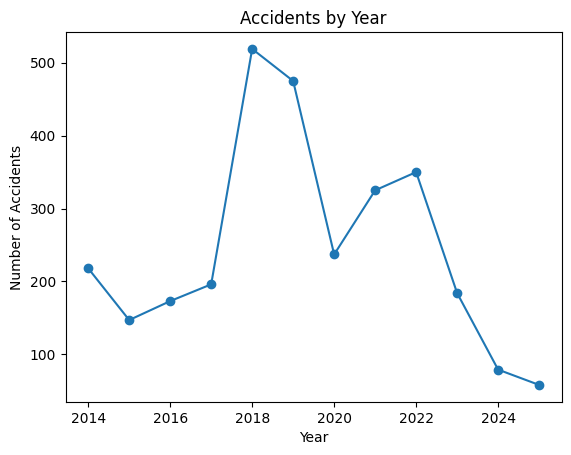

In [143]:
year_data = df["year"].value_counts().sort_index()
year_data.plot(kind="line", marker="o")
plt.title("Accidents by Year")
plt.xlabel("Year")
plt.ylabel("Number of Accidents")
plt.show()

In [144]:
total_deaths = df["number_of_deaths"].sum()
print("Total deaths:", total_deaths)
total_injured = df["number_of_injured"].sum()
print("Total injured:", total_injured)

Total deaths: 30250
Total injured: 33734


In [145]:
total = total_deaths + total_injured
table = {
    "Category": ["Deaths", "Injured"],
    "Total": [total_deaths, total_injured],
    "Percentage (%)": [
        round((total_deaths/total)*100, 2),
        round((total_injured/total)*100, 2)
    ]
}
result_table = pd.DataFrame(table)
result_table

,Category,Total,Percentage (%)
0,Deaths,30250,47.28
1,Injured,33734,52.72


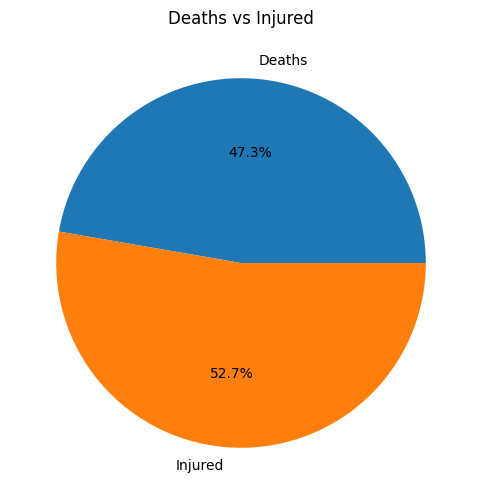

In [146]:
labels = ["Deaths", "Injured"]
values = [total_deaths, total_injured]
plt.figure(figsize=(6,6))
plt.pie(values, labels=labels, autopct="%1.1f%%")
plt.title("Deaths vs Injured")
plt.show()

In [147]:
percent = df["time_category"].value_counts(normalize=True) * 100
percent = percent.round(2).astype(str) + "%"
print(percent)

time_category
Afternoon    45.56%
Morning      28.91%
Night        25.53%
Name: proportion, dtype: str


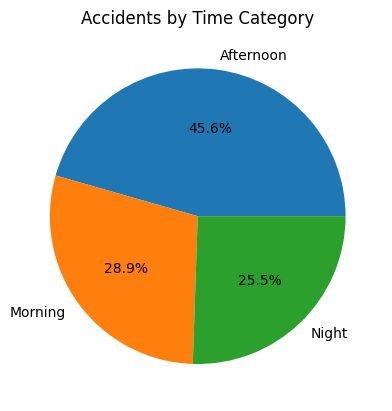

In [148]:
percent = df["time_category"].value_counts(normalize=True) * 100
percent.plot(kind="pie", autopct="%1.1f%%")
plt.title("Accidents by Time Category")
plt.ylabel("") 
plt.show()

In [149]:
df["vehicle_type"] = df["vehicle_type"].str.strip().str.title()
top10 = df["vehicle_type"].value_counts().head(10).reset_index()
top10.columns = ["Vehicle", "Number of Accidents"]
top10

,Vehicle,Number of Accidents
0,Unknown,612
1,Bus,277
2,Truck,127
3,Motorcycle,76
4,Car,58
5,"Motorcycle, Truck",38
6,Bus And Truck,31
7,"Bus, Auto-Rickshaw",30
8,"Truck, Motorbike",30
9,"Truck, Motorcycle",29


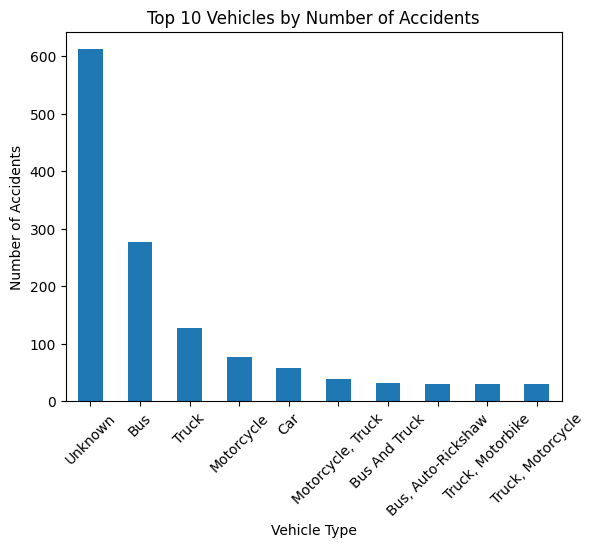

In [150]:
df["vehicle_type"] = df["vehicle_type"].str.strip().str.title()
top10_vehicle = df["vehicle_type"].value_counts().head(10)
top10_vehicle.plot(kind="bar")
plt.title("Top 10 Vehicles by Number of Accidents")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=45)
plt.show()

In [151]:
district_table = df["district"].value_counts().head(10).reset_index()
district_table.columns = ["District", "Number of Accidents"]
district_table

,District,Number of Accidents
0,dhaka,501
1,Unknown,107
2,chattogram,102
3,gazipur,86
4,sirajganj,62
5,mymensingh,56
6,cumilla,54
7,sylhet,54
8,narayanganj,53
9,chittagong,49


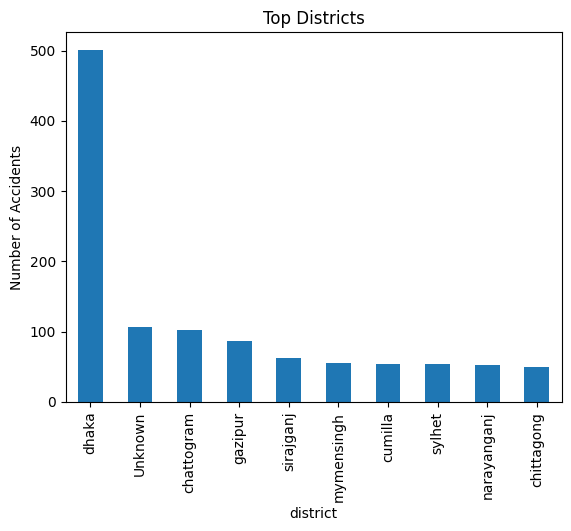

In [152]:
df["district"].value_counts().head(10).plot(kind="bar")
plt.title("Top Districts")
plt.ylabel("Number of Accidents")
plt.show()

In [153]:
hour_table = df["hour"].value_counts().sort_index().reset_index()
hour_table.columns = ["Hour", "Number of Accidents"]
hour_table

,Hour,Number of Accidents
0,0,37
1,1,2
2,3,2
3,8,65
4,9,183
5,10,255
6,11,312
7,12,266
8,13,287
9,14,214


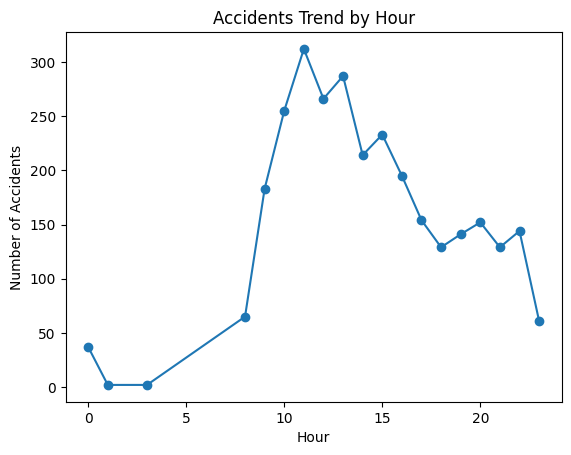

In [154]:
df["hour"].value_counts().sort_index().plot(kind="line", marker="o")

plt.title("Accidents Trend by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Accidents")

plt.show()